In [1]:
import sympy as sp

# Create 3 complex numbers using sympy
z1 = sp.symbols('z1')
z2 = sp.symbols('z2')
z3 = sp.symbols('z3')

z1 = 2 + 3 * sp.I
z2 = -1 - sp.I * sp.Rational(1, 2)
z3 = sp.Rational(5, 2) + 4 * sp.I

In [2]:
from IPython.display import display, Math

def display_large(expr):
    """Display a sympy expression in LaTeX with large font size."""
    display(Math(r"\large{%s}" % sp.latex(expr)))

def display_huge(expr):
    """Display a sympy expression in LaTeX with huge font size."""
    display(Math(r"\huge{%s}" % sp.latex(expr)))



In [3]:
display_large(z1)
display_large(z2)
display_large(z3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
print("z1 real part:", sp.re(z1))
print("z1 imaginary part:", sp.im(z1))
print('='*20)

print("z2 real part:", sp.re(z2))
print("z2 imaginary part:", sp.im(z2))
print('='*20)

print("z3 real part:", sp.re(z3))
print("z3 imaginary part:", sp.im(z3))
print('='*20)


z1 real part: 2
z1 imaginary part: 3
z2 real part: -1
z2 imaginary part: -1/2
z3 real part: 5/2
z3 imaginary part: 4


In [5]:
# Complex conjugate: if z = x + iy, then conjugate(z) = x - iy
# Geometrically: reflection of z across the real axis
z1_bar = sp.conjugate(z1)
z2_bar = sp.conjugate(z2)
z3_bar = sp.conjugate(z3)

print("z1 conjugate:", z1_bar)
print("z2 conjugate:", z2_bar)
print("z3 conjugate:", z3_bar)
print("=" * 20)

display_large(z1_bar)
display_large(z2_bar)
display_large(z3_bar)

# Property: z * conjugate(z) = |z|^2 (always a non-negative real number)
display_large(sp.simplify(z1 * z1_bar))
display_large(sp.Abs(z1) ** 2)

z1 conjugate: 2 - 3*I
z2 conjugate: -1 + I/2
z3 conjugate: 5/2 - 4*I


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

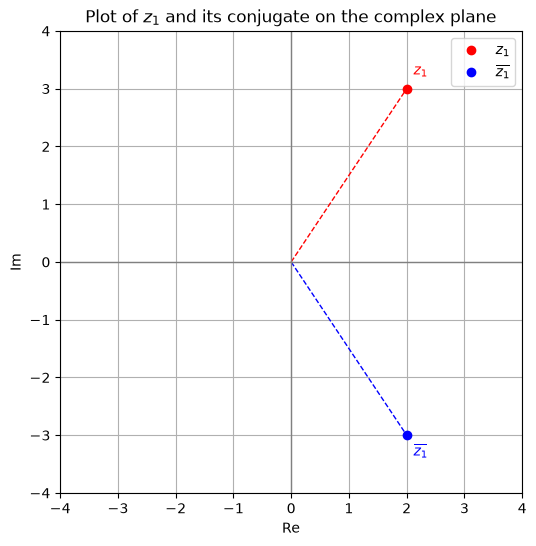

In [18]:
import matplotlib.pyplot as plt

# Plot z1 and its conjugate on the complex plane
fig, ax = plt.subplots(figsize=(6, 6))

# Extract real and imaginary parts
z1_real, z1_imag = float(sp.re(z1)), float(sp.im(z1))
z1_bar_real, z1_bar_imag = float(sp.re(z1_bar)), float(sp.im(z1_bar))

# Find min/max for square axis
real_vals = [z1_real, z1_bar_real]
imag_vals = [z1_imag, z1_bar_imag]
min_val = min(min(real_vals), min(imag_vals))
max_val = max(max(real_vals), max(imag_vals))
center = (max_val + min_val) / 2
half_range = (max_val - min_val) / 2 + 1   # margin=1

# Make sure the plot is square in the x-y axes sense
ax.set_xlim(center - half_range, center + half_range)
ax.set_ylim(center - half_range, center + half_range)

# Plot z1
ax.plot(z1_real, z1_imag, 'ro', label='$z_1$')
ax.annotate(r'$z_1$', (z1_real, z1_imag), textcoords="offset points", xytext=(10,10), ha='center', color='r')

# Plot conjugate of z1
ax.plot(z1_bar_real, z1_bar_imag, 'bo', label=r'$\overline{z_1}$')
ax.annotate(r'$\overline{z_1}$', (z1_bar_real, z1_bar_imag), textcoords="offset points", xytext=(10,-15), ha='center', color='b')

# Add dotted lines for z1 and its conjugate
ax.plot([0, z1_real], [0, z1_imag], 'r--', lw=1, label=None)  # Dotted line for z1
ax.plot([0, z1_bar_real], [0, z1_bar_imag], 'b--', lw=1, label=None)  # Dotted line for conjugate

# Draw x and y axes
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_aspect('equal', adjustable='box')  # Ensures the grid is perfectly square
ax.legend()
ax.set_title("Plot of $z_1$ and its conjugate on the complex plane")
plt.grid(True)
plt.show()

In [6]:
# Represent each complex number as a 2D vector [Re(z), Im(z)]
# by extracting the real and imaginary parts and constructing sympy Matrix objects.

vec_z1 = sp.Matrix([sp.re(z1), sp.im(z1)])
vec_z2 = sp.Matrix([sp.re(z2), sp.im(z2)])
vec_z3 = sp.Matrix([sp.re(z3), sp.im(z3)])

display_large(vec_z1)
display_large(vec_z2)
display_large(vec_z3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

因為 $\arctan$ 有盲點，所以當我們要用 $\arctan$ 來計算 $\text{Arg}(z)$ 時，必須根據 $x$ 和 $y$ 所在的象限進行**分段修正**：

$$\text{Arg}(z) =  \begin{cases}  \arctan\left(\frac{y}{x}\right) & \text{if } x > 0 \quad (\text{第一、四象限}) \\ \arctan\left(\frac{y}{x}\right) + \pi & \text{if } x < 0, y \ge 0 \quad (\text{第二象限}) \\ \arctan\left(\frac{y}{x}\right) - \pi & \text{if } x < 0, y < 0 \quad (\text{第三象限}) \\ \frac{\pi}{2} & \text{if } x = 0, y > 0 \quad (\text{正 }y\text{ 軸}) \\ -\frac{\pi}{2} & \text{if } x = 0, y < 0 \quad (\text{負 }y\text{ 軸}) \\ \text{未定義} & \text{if } x = 0, y = 0 \quad (\text{原點}) \end{cases}$$


In [7]:
# Express z1 in Euler (polar) form: r*exp(i*theta)
r1, theta1 = sp.Abs(z1), sp.arg(z1)
z1_euler = r1 * sp.exp(sp.I * theta1)
display_large(z1_euler)

<IPython.core.display.Math object>

In [8]:
display_huge(z1_euler)

<IPython.core.display.Math object>

In [9]:
display(z2)
z2_euler = sp.Abs(z2) * sp.exp(sp.I * sp.arg(z2))
display_huge(z2_euler)

-1 - I/2

<IPython.core.display.Math object>

In [10]:

display(z3)
z3_euler = sp.Abs(z3) * sp.exp(sp.I * sp.arg(z3))
display_huge(z3_euler)

z3_complex = sp.simplify(sp.expand_complex(z3_euler))
display(z3_complex)

5/2 + 4*I

<IPython.core.display.Math object>

5/2 + 4*I

In [11]:
z4 = 8

# Take the 6th roots of z4
n = 6
roots_z4 = [sp.root(z4, n) * sp.exp(sp.I * 2 * sp.pi * k / n) for k in range(n)]

for k, root in enumerate(roots_z4):
    display_huge(sp.Eq(sp.Symbol(f'z4_{{root_{k}}}'), root))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [12]:
roots_z4_cartesian = [sp.simplify(sp.expand_complex(root)) for root in roots_z4]
for k, root_cart in enumerate(roots_z4_cartesian):
    display_huge(sp.Eq(sp.Symbol(f'z4_{{root_{k}}}'), root_cart))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

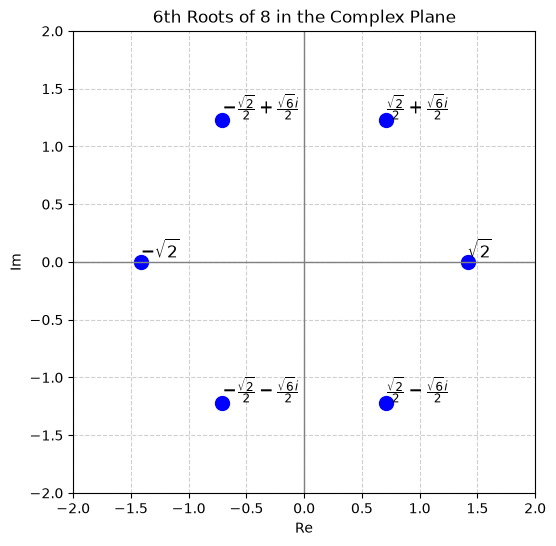

In [13]:
import matplotlib.pyplot as plt

# Prepare data for plotting
roots_x = [sp.re(root.evalf()) for root in roots_z4_cartesian]
roots_y = [sp.im(root.evalf()) for root in roots_z4_cartesian]

plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.scatter(roots_x, roots_y, color='blue', s=100)

for i, (x, y) in enumerate(zip(roots_x, roots_y)):
    plt.text(x, y, f"${sp.latex(roots_z4_cartesian[i])}$", fontsize=12, ha='left', va='bottom')

plt.title('6th Roots of 8 in the Complex Plane')
plt.xlabel('Re')
plt.ylabel('Im')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()